# Indie Studio Ads Optimizer: Predicting Premium Upgrade & Total Spend


## 1. Data Overview
Tujuan : Melihat dan mengenalkan data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("indie_studio_players.csv")
df.head()

,user_id,days_active,avg_session_time,community_engagement,total_spend,is_premium
0,1,137,228,73,365853,0
1,2,316,146,71,362463,1
2,3,112,128,44,259611,0
3,4,134,112,79,259588,0
4,5,222,45,7,144494,0


In [3]:
df.tail()

,user_id,days_active,avg_session_time,community_engagement,total_spend,is_premium
995,996,102,191,23,265288,0
996,997,69,58,50,87808,0
997,998,286,81,72,291620,1
998,999,264,69,85,228668,1
999,1000,55,112,50,208741,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   user_id               1000 non-null   int64
 1   days_active           1000 non-null   int64
 2   avg_session_time      1000 non-null   int64
 3   community_engagement  1000 non-null   int64
 4   total_spend           1000 non-null   int64
 5   is_premium            1000 non-null   int64
dtypes: int64(6)
memory usage: 47.0 KB


In [5]:
df.isnull().sum()

user_id                 0
days_active             0
avg_session_time        0
community_engagement    0
total_spend             0
is_premium              0
dtype: int64

Keterangan : Data bersih dan siap di analisis.

## 2. Descriptive Statistics
Tujuan: Memahami karakter umum data.

In [6]:
df.mean()

user_id                    500.500
days_active                177.673
avg_session_time           118.858
community_engagement        49.518
total_spend             289673.572
is_premium                   0.291
dtype: float64

In [7]:
df.median()

user_id                    500.5
days_active                177.0
avg_session_time           118.0
community_engagement        48.0
total_spend             265084.5
is_premium                   0.0
dtype: float64

Insight :
- days_active = Rata-rata player aktif di angka 178 hari.
- avg_session_time = Mayoritas player punya waktu bermain hampir 2 jam setiap hari.
- community_engagement = Kebanyakan player tidak terlalu aktif di komunitas, angka engagement hanya tercatat tidak lebih dari 50.
- total_spend = Pengeluaran player untuk game mayoritas berkisar di angka 265-290 ribu rupiah.

## 3. Data Distribution
Tujuan : Memvisualisasikan distribusi data.

[Text(0, 0, '709'), Text(0, 0, '291')]

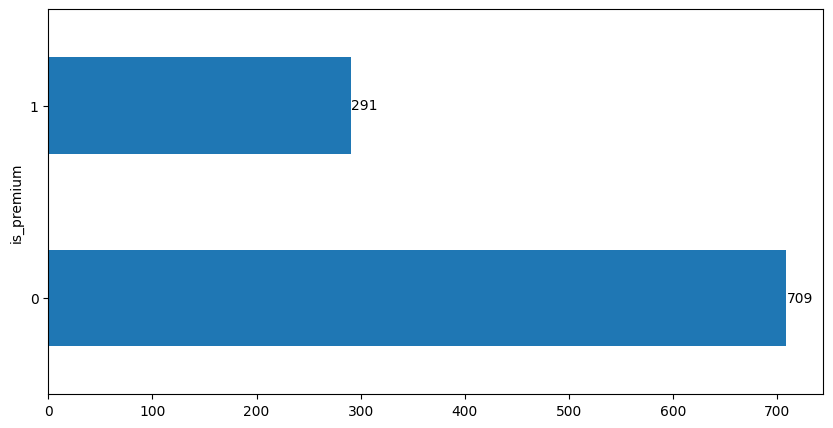

In [8]:
ax = df["is_premium"].value_counts().plot(kind="barh", figsize=(10, 5))
ax.bar_label(ax.containers[0])


Insight : Game didominasi oleh player non premium (free-to-play).

<Axes: ylabel='Frequency'>

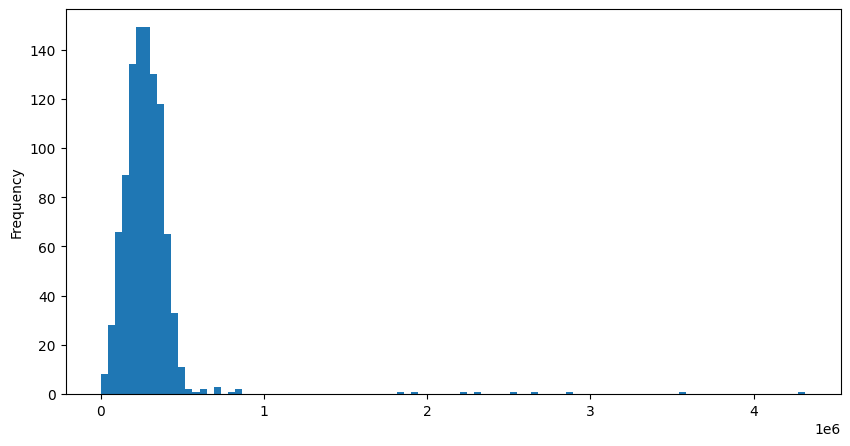

In [9]:
df["total_spend"].plot(kind="hist", bins=100, figsize=(10, 5))

Insight : Distribusi total spend menunjukkan dominasi pengeluaran player dibawah angka 500000 (dalam rupiah), meski dalam kejadian langka terdapat pengeluaran besar hingga lebih dari 4 juta rupiah.

## 4. Correlation Analysis
Tujuan: Melihat hubungan antar variabel.

<Axes: >

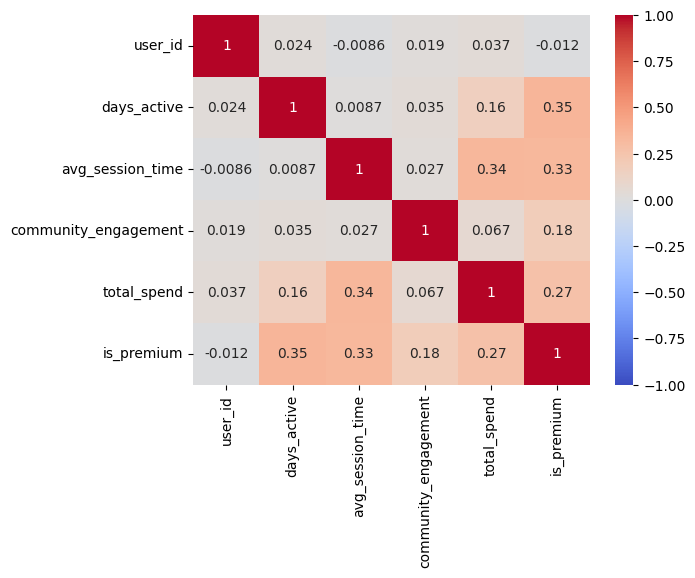

In [13]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)

Insight:
- Variabel `is_premium` mempunyai korelasi paling kuat dengan `days_active` diikuti dengan `avg_session_time`. Hal ini menandakan bahwa peningkatan kemungkinan player akan premium terjadi paling tinggi atas pengaruh jumlah hari aktif dan waktu bermain player. Semakin panjang waktu bermain dan semakin banyak hari aktif, semakin tinggi pula kemungkinan player akan premium.
- Selain itu, terdapat korelasi cukup tinggi antara `total_spend` dengan `avg_session_time`. Hal ini menjadi pendukung bahwa kemungkinan player akan mengeluarkan uang untuk pembelian jika player tersebut suka menghabiskan waktu lama bermain game tersebut.